# Audio Speaker Labeling

Demonstrates how `build_labeled_audio()` in `pipelines.py` assigns candidate names
to every audio segment across all 28 debates.

**Two-stage pipeline:**
1. **k=3 per-debate clustering** — speaker embeddings (512-d pyannote vectors) are
   clustered into 3 groups per debate: candidate A, candidate B, host.
2. **Cross-debate centroid anchoring** — each candidate appears in 7 debates. Their
   cluster centroid should be consistent across those 7. We find the best-matching
   centroid per candidate per debate, average them into a global centroid, then
   re-assign labels using cosine distance to that global centroid.

This is the audio equivalent of `visual_label.ipynb`.

## Setup

In [ ]:
import sys
sys.path.insert(0, 'multivideo_analysis')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2
from pipelines import build_labeled_audio, CANDIDATES, CAND_COLOR, extract_candidates

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DEMO_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

## Step 1 — Speaker embeddings: what are they?

In [ ]:
# Load audio data WITH speaker labels already assigned
data = build_labeled_audio()
debate_videos = sorted(v for v in data['video'].unique() if 'vs' in v)

# Focus on one demo debate first
demo = data[data['video'] == DEMO_DEBATE].copy()
E = np.stack(demo['speak_embeddings'].values)
print(f'Debate: {DEMO_DEBATE}')
print(f'Segments: {len(demo)} | Embedding shape: {E.shape}')
print(demo['speaker'].value_counts())

## Step 2 — Why k=3? Elbow curve + silhouette for one debate

Each debate has exactly 3 speakers: candidate A, candidate B, host.
The elbow curve should show a clear kink at k=3.

In [ ]:
E_raw = np.stack(demo['speak_embeddings'].values)

# Elbow
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E_raw).inertia_
            for k in range(1, 7)]

# Silhouette (needs k >= 2)
sil = [silhouette_score(E_raw, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(E_raw))
       for k in range(2, 7)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, 7), inertias, marker='o')
ax1.axvline(3, color='red', ls='--', label='k=3')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve — speaker embeddings'); ax1.legend()

ax2.plot(range(2, 7), sil, marker='o', color='orange')
ax2.axvline(3, color='red', ls='--', label='k=3')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette — speaker embeddings'); ax2.legend()

plt.tight_layout(); plt.show()

## Step 3 — k=3 clusters in PCA space (one debate)

In [ ]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
raw_labels = km.fit_predict(E_raw)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E_raw)
v1, v2 = pca.explained_variance_ratio_ * 100

cmap = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}
true_colors = [CAND_COLOR.get(s, '#aaaaaa') for s in demo['speaker']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ki in range(3):
    m = raw_labels == ki
    ax1.scatter(E_2d[m, 0], E_2d[m, 1], c=cmap[ki], alpha=0.7, s=40, label=f'Cluster {ki}')
ax1.set_title(f'k=3 raw clusters (PCA, {v1:.0f}+{v2:.0f}% var)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.legend()

for spk in demo['speaker'].unique():
    m = demo['speaker'] == spk
    c = CAND_COLOR.get(spk, '#aaaaaa')
    ax2.scatter(E_2d[m.values, 0], E_2d[m.values, 1], c=c, alpha=0.7, s=40, label=spk)
ax2.set_title('Ground-truth speaker identity (from cross-debate pipeline)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.legend()

plt.suptitle(f'Speaker embeddings — {DEMO_DEBATE}', fontsize=12)
plt.tight_layout(); plt.show()

## Step 4 — Silhouette across all 28 debates

A high silhouette score means the 3 speakers are well-separated in embedding space
for that debate. Low scores (< 0.25) flag debates where labels may be unreliable.

In [ ]:
sil_rows = []
for v in debate_videos:
    sub = data[data['video'] == v]
    E_v = np.stack(sub['speak_embeddings'].values)
    labels_v = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(E_v)
    if len(set(labels_v)) > 1:
        s = silhouette_score(E_v, labels_v)
    else:
        s = 0.0
    sil_rows.append({'video': v, 'silhouette': s, 'n_segments': len(sub)})

sil_df = pd.DataFrame(sil_rows).sort_values('silhouette', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ca02c' if s >= 0.45 else '#ff7f0e' if s >= 0.25 else '#d62728'
          for s in sil_df['silhouette']]
ax.barh(sil_df['video'].str.replace('_', ' '), sil_df['silhouette'], color=colors)
ax.axvline(0.25, color='red',    ls='--', lw=1.2, label='low quality (< 0.25)')
ax.axvline(0.45, color='orange', ls='--', lw=1.2, label='medium (0.25-0.45)')
ax.set_xlabel('Silhouette score'); ax.set_title('Speaker separation quality per debate')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print(f'Mean silhouette: {sil_df["silhouette"].mean():.3f}')
print(f'High quality (>= 0.45): {(sil_df["silhouette"] >= 0.45).sum()}/{len(sil_df)} debates')
print(f'Low quality  (<  0.25): {(sil_df["silhouette"] <  0.25).sum()}/{len(sil_df)} debates')

## Step 5 — Cross-debate centroid anchoring: how names get assigned

Each candidate appears in 7 debates. In each debate their cluster centroid should be
the one most consistent with their centroids in the OTHER 6 debates (smallest cosine
distance to the nearest centroid in each other debate). We average those per-debate
"best centroids" into one global centroid per candidate, then assign labels by cosine
distance.

In [ ]:
# Show global centroid consistency: for each candidate, how far are their
# per-debate centroids from their own global centroid vs other candidates?

cand_data = data[data['speaker'].isin(CANDIDATES)].copy()

cand_debate_rows = []
for (spk, vid), grp in cand_data.groupby(['speaker', 'video']):
    E = np.stack(grp['speak_embeddings'].values)
    cand_debate_rows.append({'speaker': spk, 'video': vid, 'centroid': E.mean(axis=0)})

cdt = pd.DataFrame(cand_debate_rows)
global_c = cdt.groupby('speaker')['centroid'].apply(
    lambda s: np.mean(np.stack(s.values), axis=0))

rows = []
for _, r in cdt.iterrows():
    d_own   = cdist(r['centroid'][None,:], global_c[r['speaker']][None,:], metric='cosine')[0,0]
    others  = [c for c in global_c.index if c != r['speaker']]
    d_other = cdist(r['centroid'][None,:],
                    np.stack(global_c[others].values), metric='cosine')[0].min()
    rows.append({'speaker': r['speaker'], 'dist_own': d_own, 'dist_nearest_other': d_other,
                 'margin': d_other - d_own})

margin_df = pd.DataFrame(rows)
order = margin_df.groupby('speaker')['dist_own'].mean().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=margin_df, x='speaker', y='dist_own', order=order,
            palette=[CAND_COLOR[c] for c in order], ax=axes[0])
axes[0].set_title('Distance to own global centroid per debate\n(lower = more consistent voice)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=margin_df, x='speaker', y='margin', order=order,
            palette=[CAND_COLOR[c] for c in order], ax=axes[1])
axes[1].axhline(0, color='grey', ls='--')
axes[1].set_title('Margin vs nearest other candidate\n(higher = more separable)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Cross-debate speaker embedding consistency', fontsize=12)
plt.tight_layout(); plt.show()

## Step 6 — Label distribution: how many segments per candidate?

The final output of `build_labeled_audio()` — segment counts per speaker.

In [ ]:
counts = (data[data['video'].isin(debate_videos)]
          .groupby('speaker')['duration']
          .agg(n_segments='count', total_min=lambda x: x.sum()/60)
          .reset_index()
          .sort_values('total_min', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAND_COLOR.get(r['speaker'], '#888888') for _, r in counts.iterrows()]
ax.barh(counts['speaker'], counts['total_min'], color=colors)
ax.set_xlabel('Total speaking time (minutes)')
ax.set_title('Speaking time per speaker across all 28 debates')
plt.tight_layout(); plt.show()
print(counts.to_string(index=False))

---
## Silhouette quality across all 28 debates

Demonstrating that k=3 works robustly across the full corpus.
Each debate is scored by its silhouette score at k=3 in the 512-dimensional embedding space.
High scores → the three speakers (candidate A, candidate B, host) are well separated.
Low scores flag debates where the host and one candidate overlap acoustically.

## Part III — Speaker separation from embeddings

We know each debate has exactly 3 speakers: candidate A, candidate B, and a TV host.
This section asks whether the speaker embeddings themselves support `k=3`, rather than forcing that assumption.
We start with a single-debate sanity check, then rank all debates by separation quality.

The silhouette score (computed in full 512-dim cosine space) quantifies separation quality per debate.

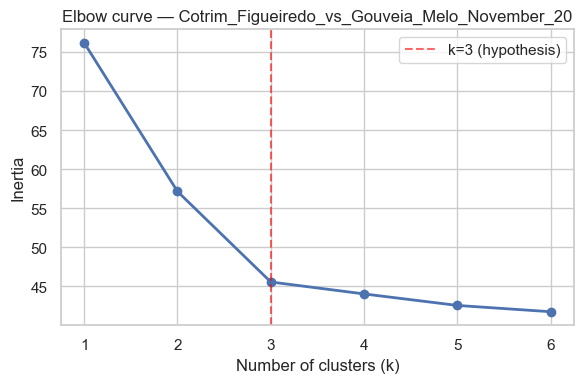

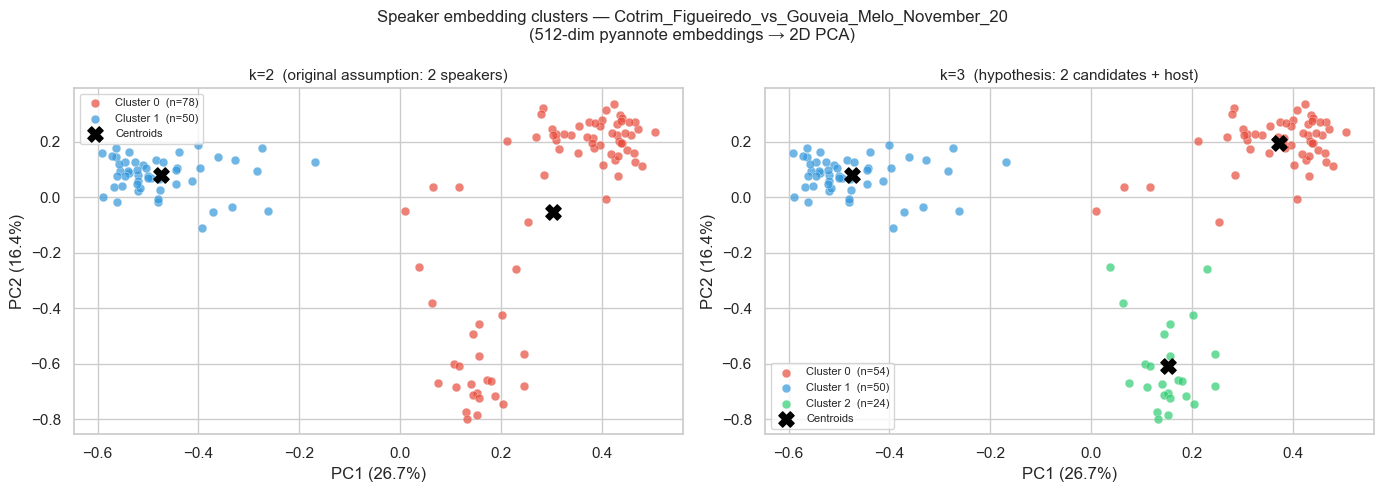

In [ ]:
# First: single debate demonstration — Cotrim vs Gouveia Melo (128 segments, clear structure)
DEMO_DEBATE = 'Cotrim_Figueiredo_vs_Gouveia_Melo_November_20'

debate = data[data['video'] == DEMO_DEBATE].copy().reset_index(drop=True)
E = np.stack(debate['speak_embeddings'].values)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), inertias, marker='o', linewidth=2)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (hypothesis)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title(f'Elbow curve — {DEMO_DEBATE}')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, k, title in zip(
    axes, [2, 3],
    ['k=2  (original assumption: 2 speakers)',
     'k=3  (hypothesis: 2 candidates + host)']
):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(E)
    for i in range(k):
        mask = labels == i
        ax.scatter(E_2d[mask, 0], E_2d[mask, 1], c=colors[i],
                   label=f'Cluster {i}  (n={mask.sum()})',
                   alpha=0.7, s=40, edgecolors='white', linewidth=0.3)
    centroids_2d = pca.transform(km.cluster_centers_)
    ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
               c='black', marker='X', s=120, zorder=5, label='Centroids')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f'PC1 ({var1:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2:.1f}%)')
    ax.legend(fontsize=8)

plt.suptitle(f'Speaker embedding clusters — {DEMO_DEBATE}\n(512-dim pyannote embeddings → 2D PCA)', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 Separation quality across all 28 debates

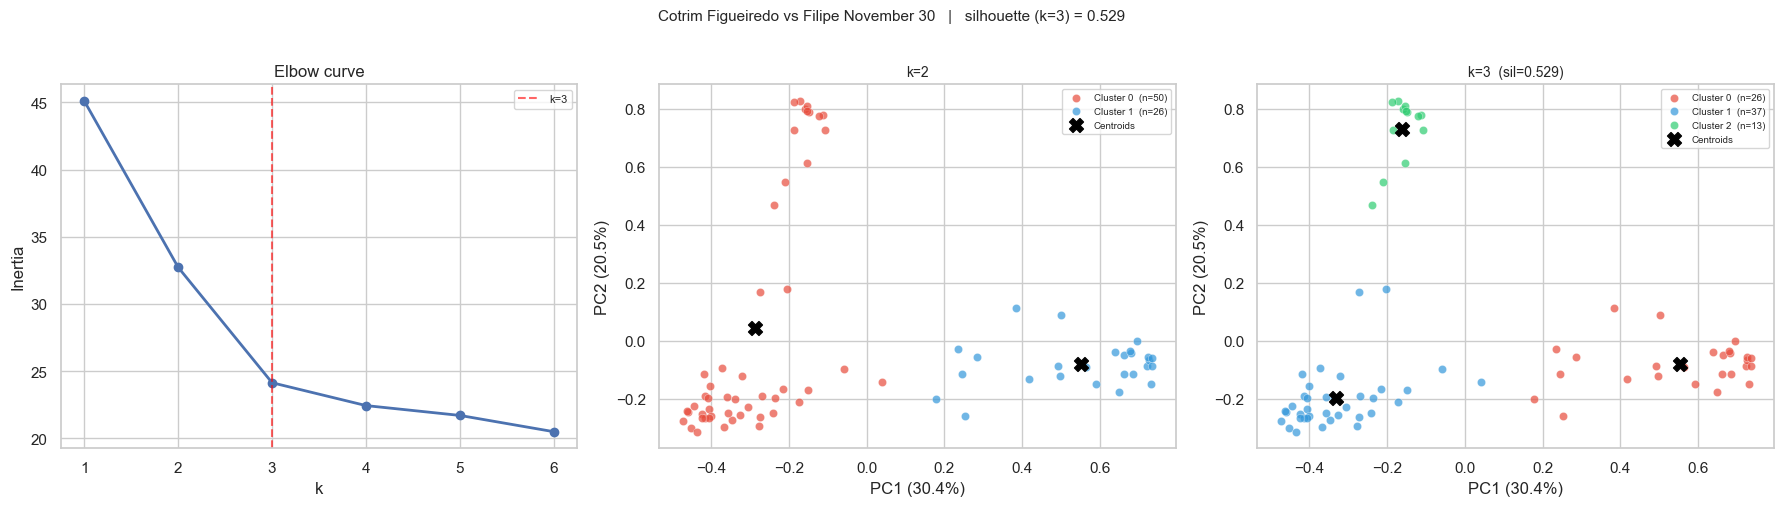

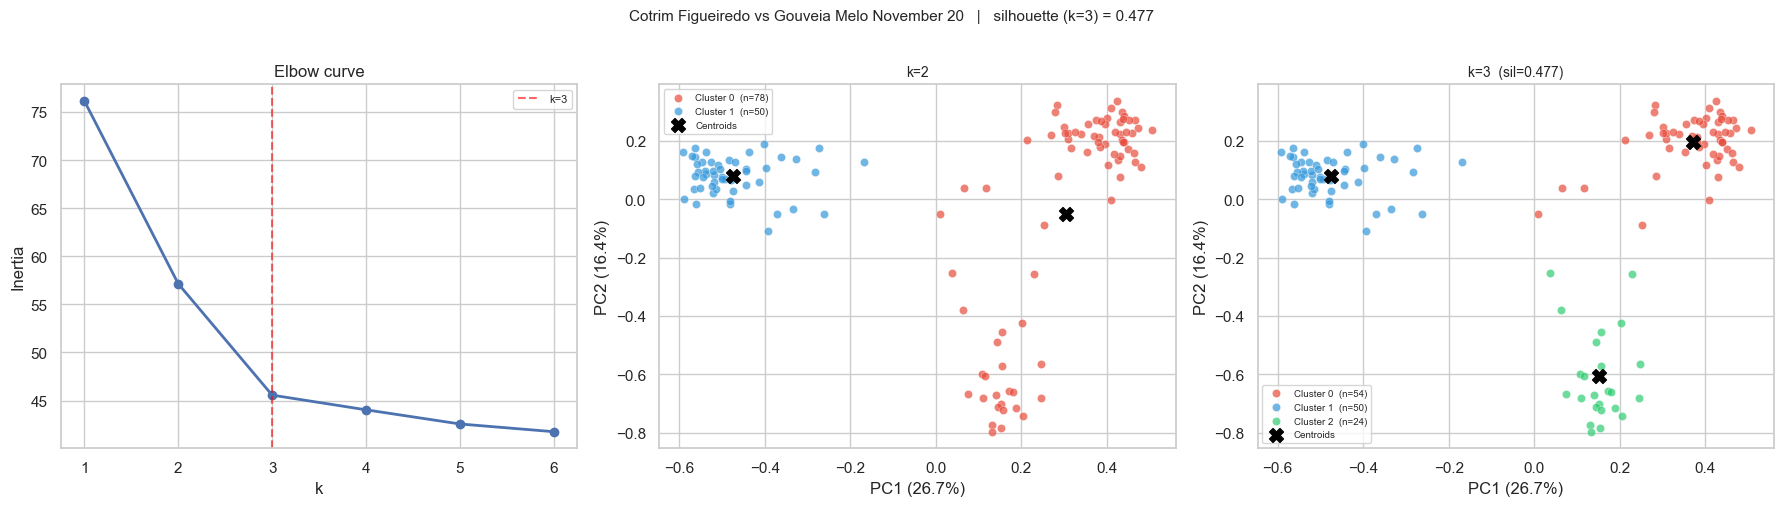

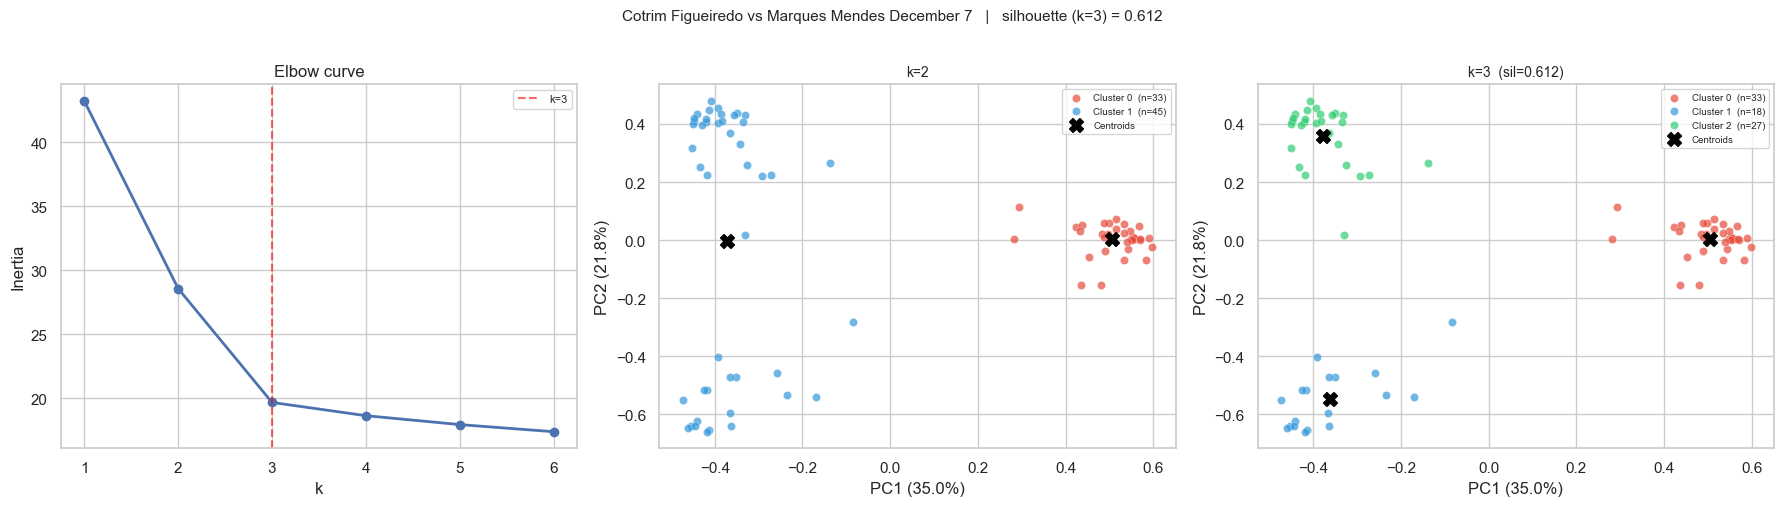

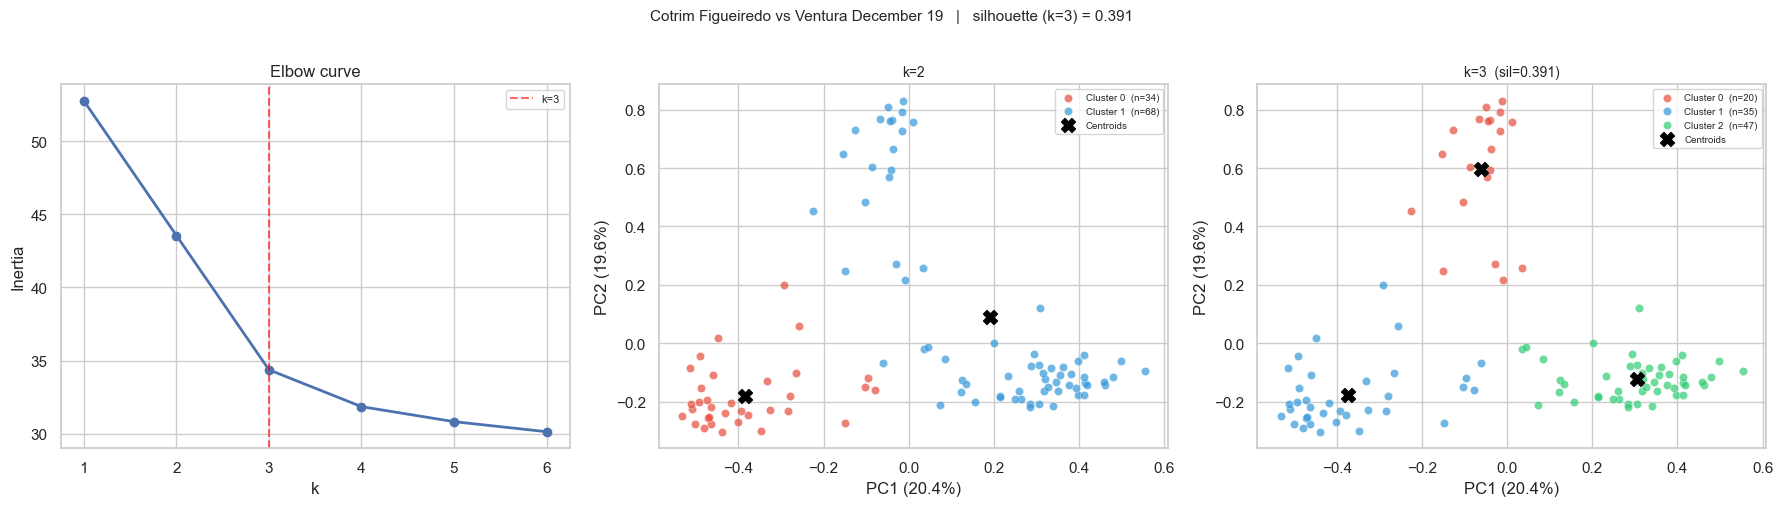

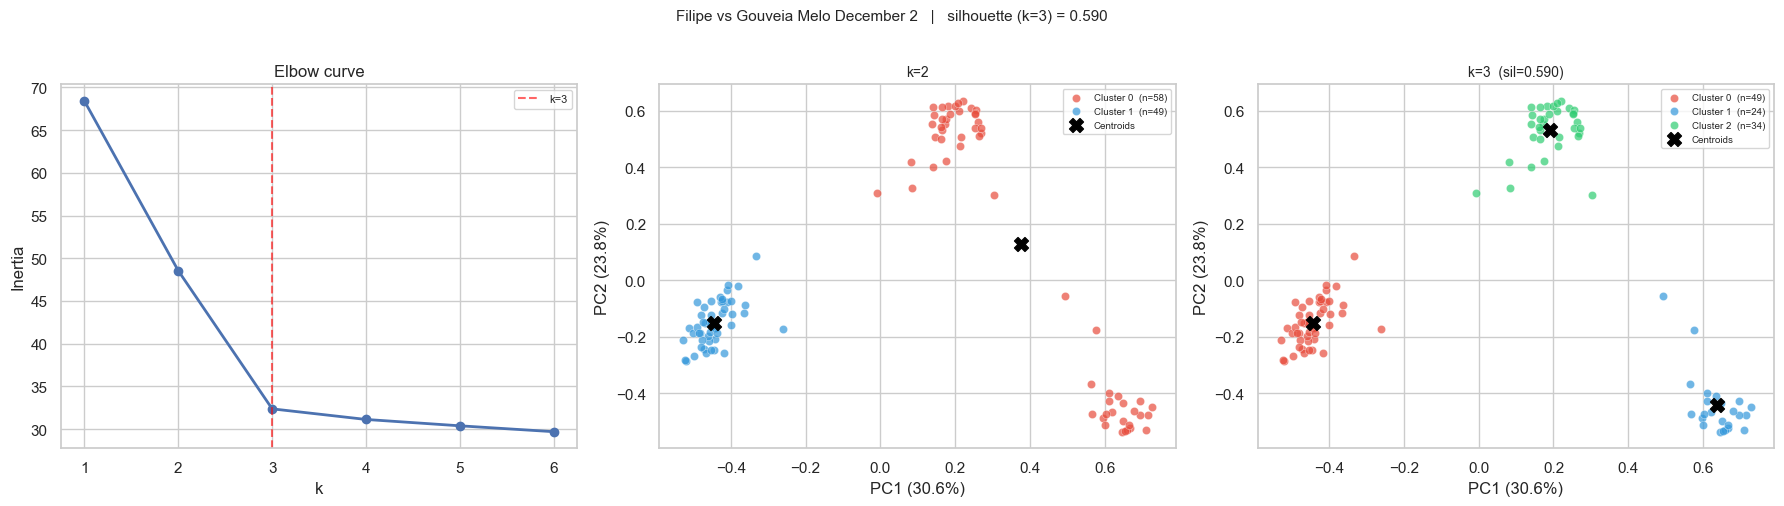

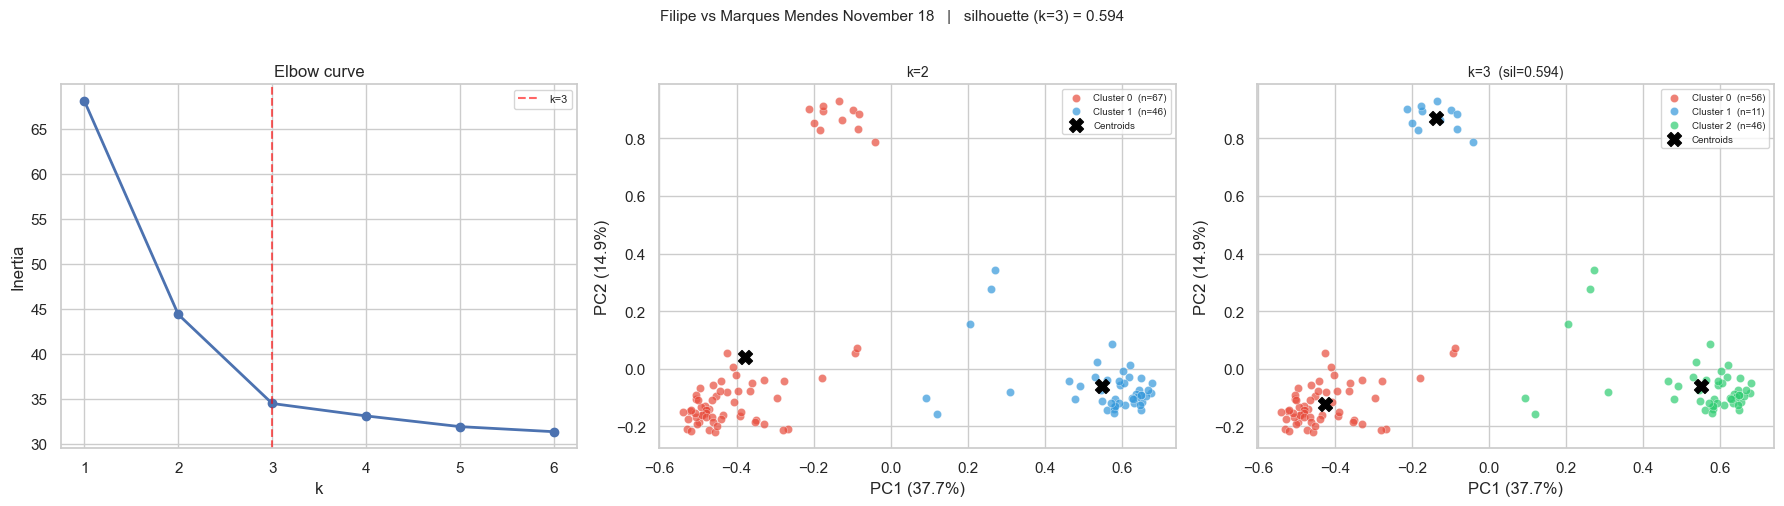

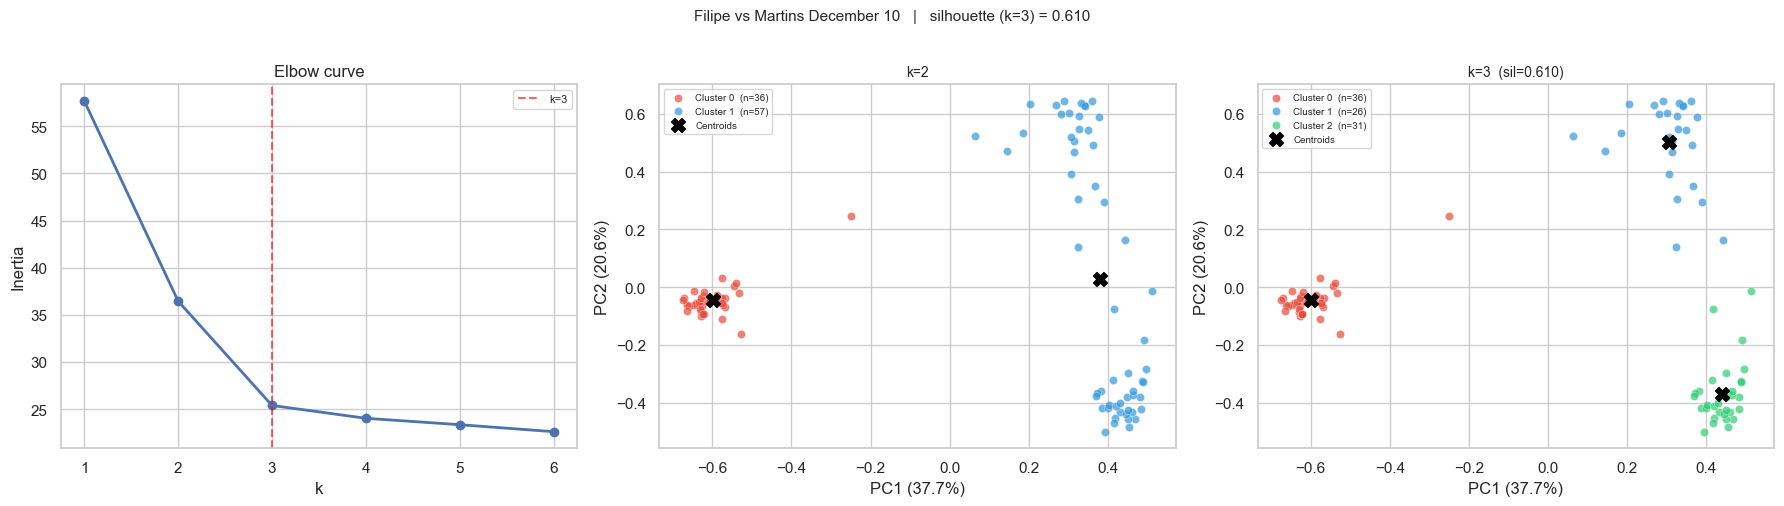

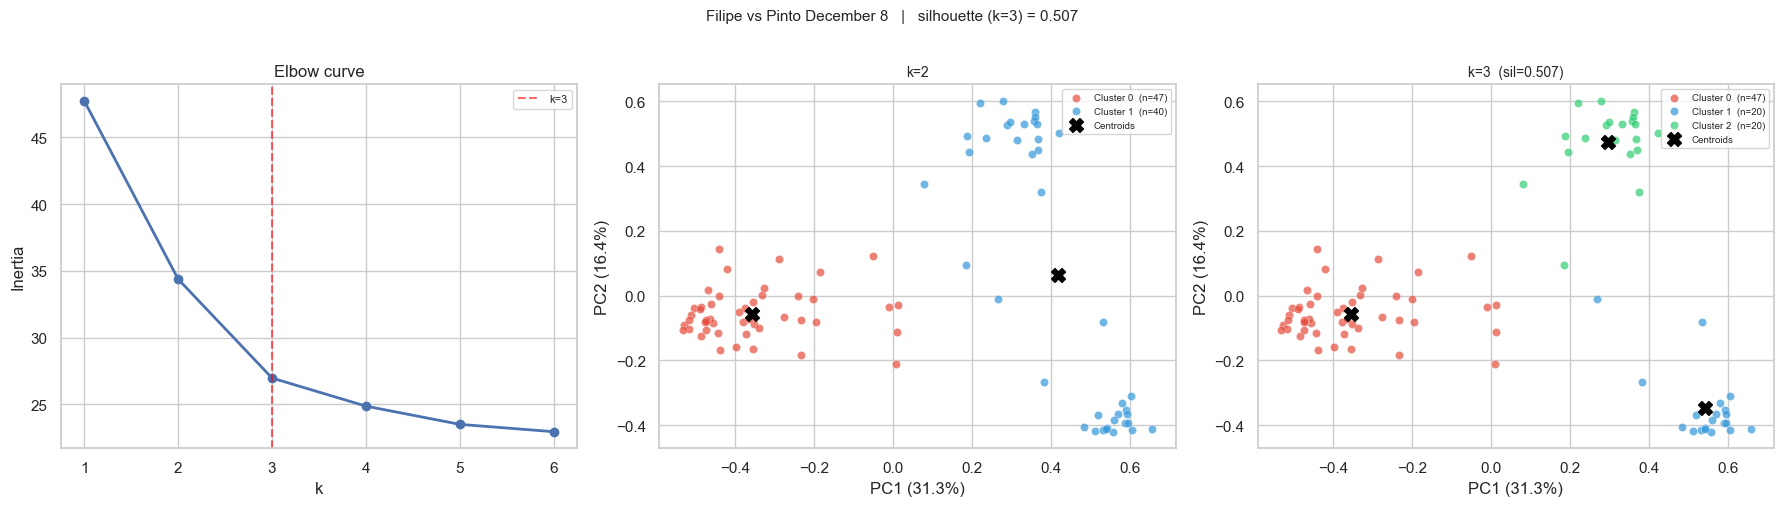

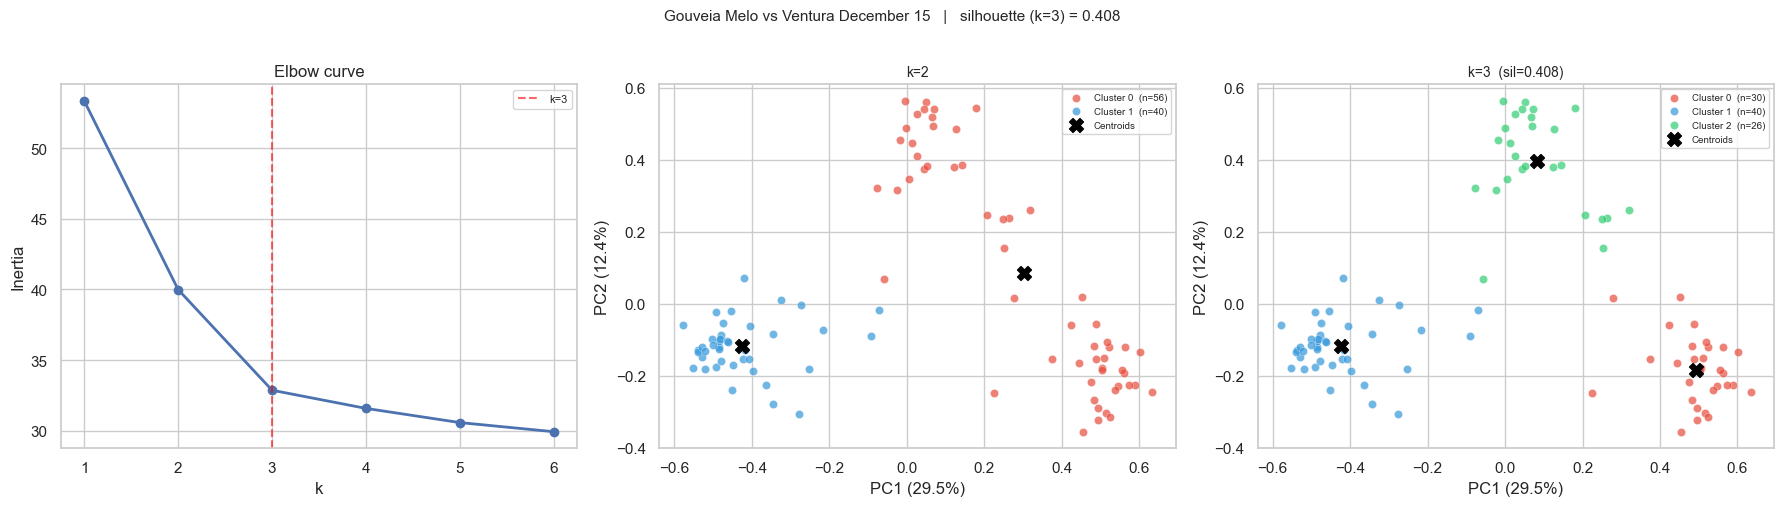

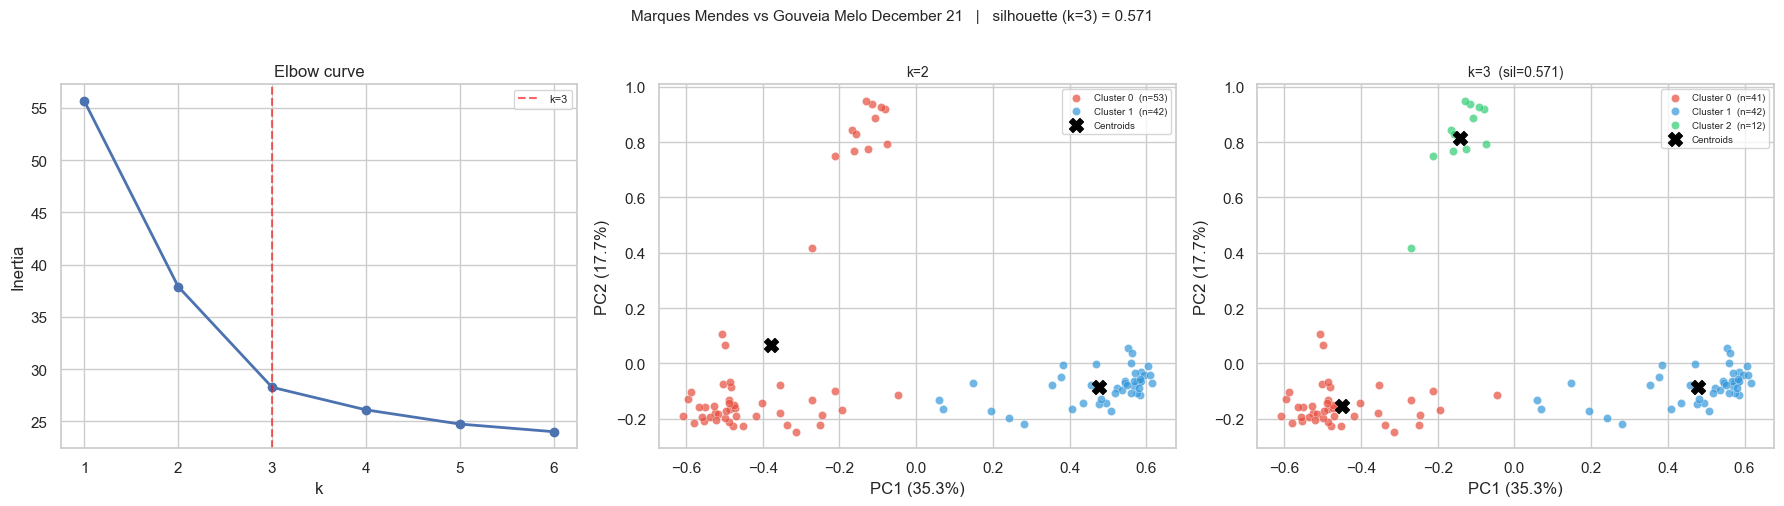

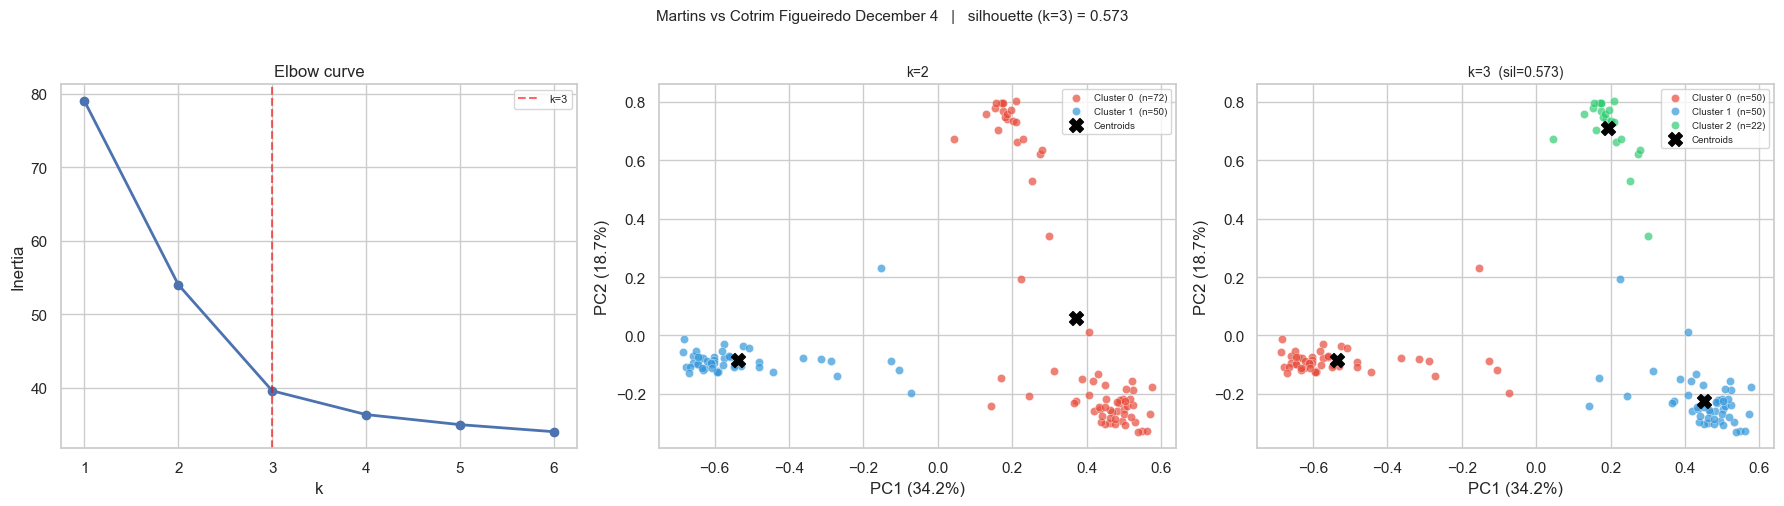

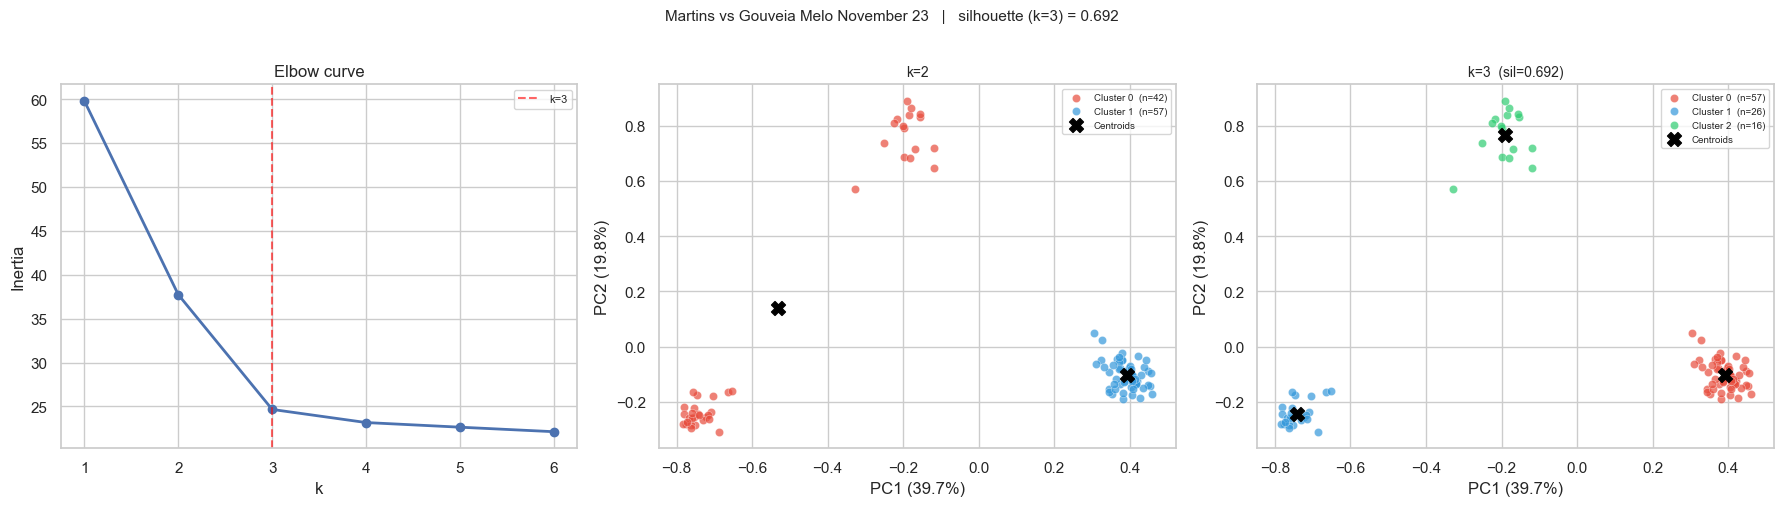

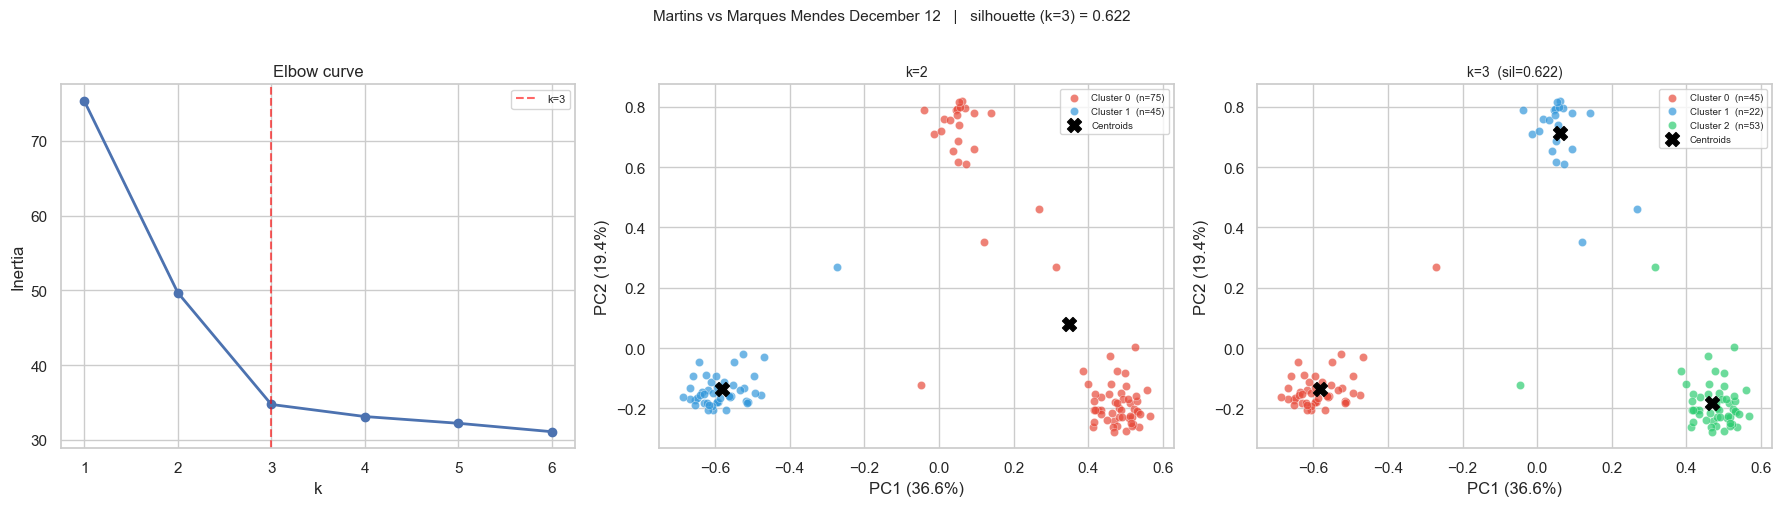

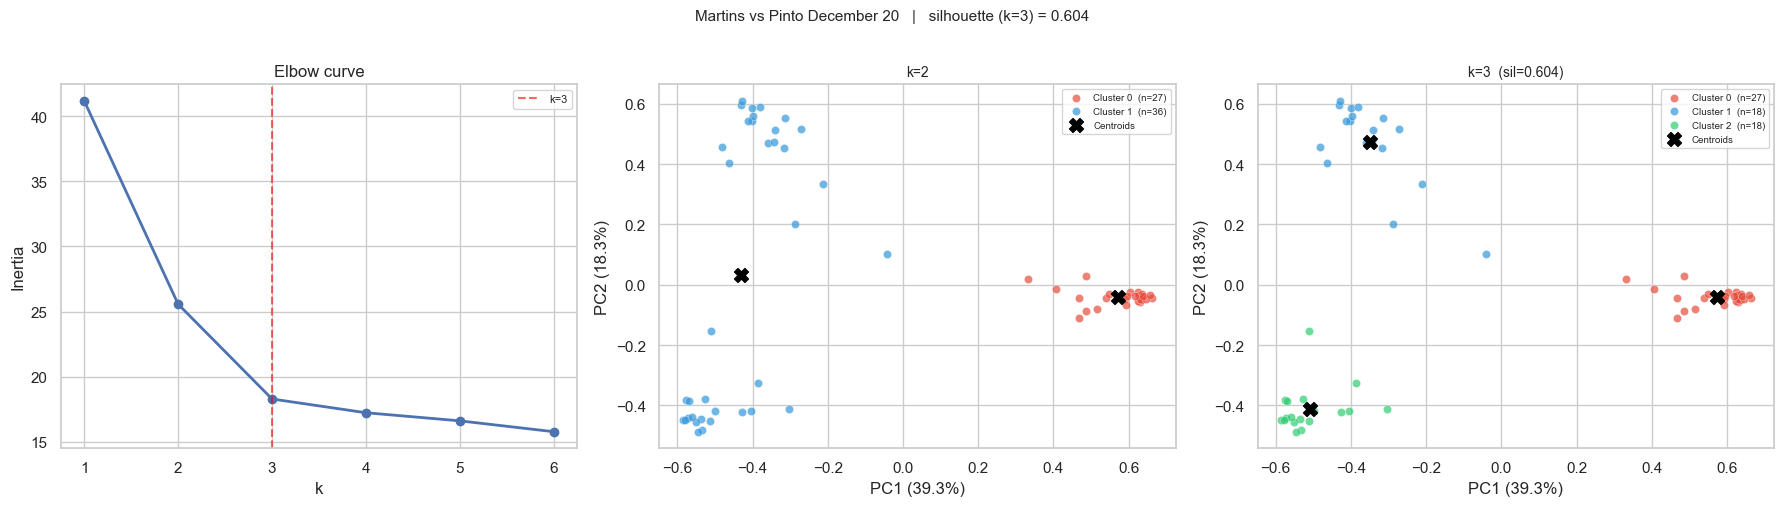

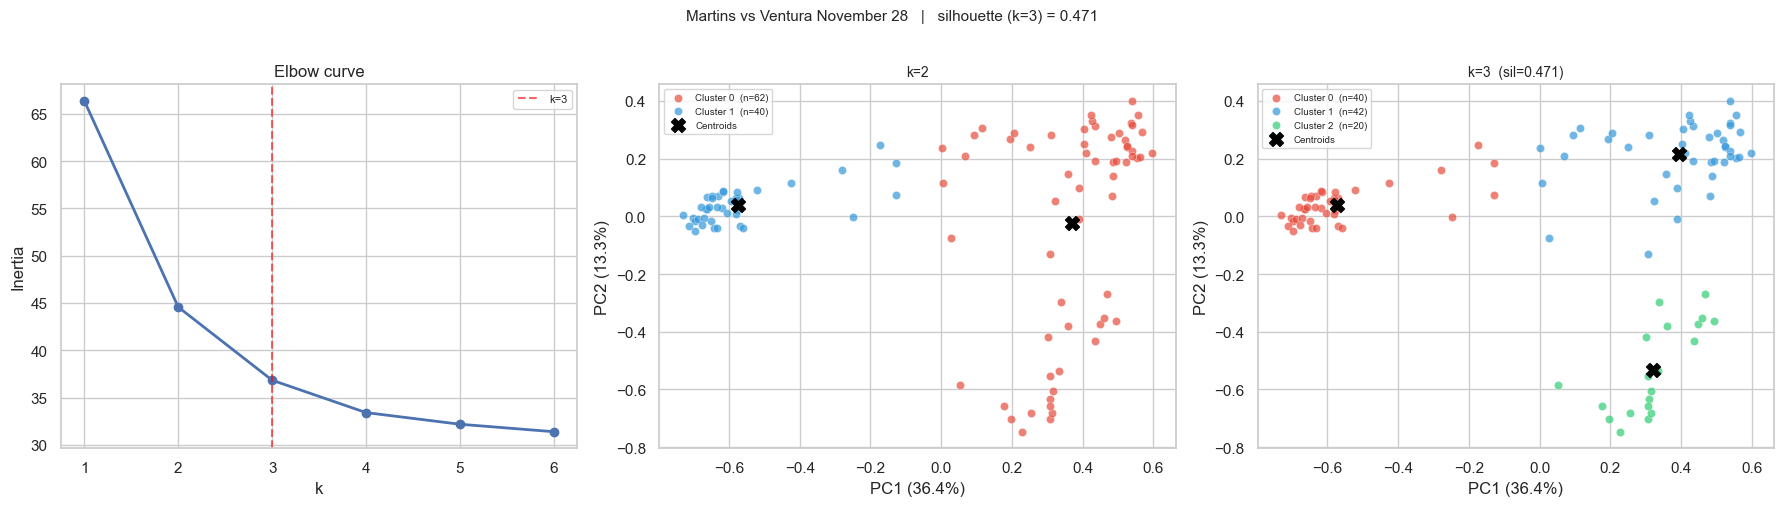

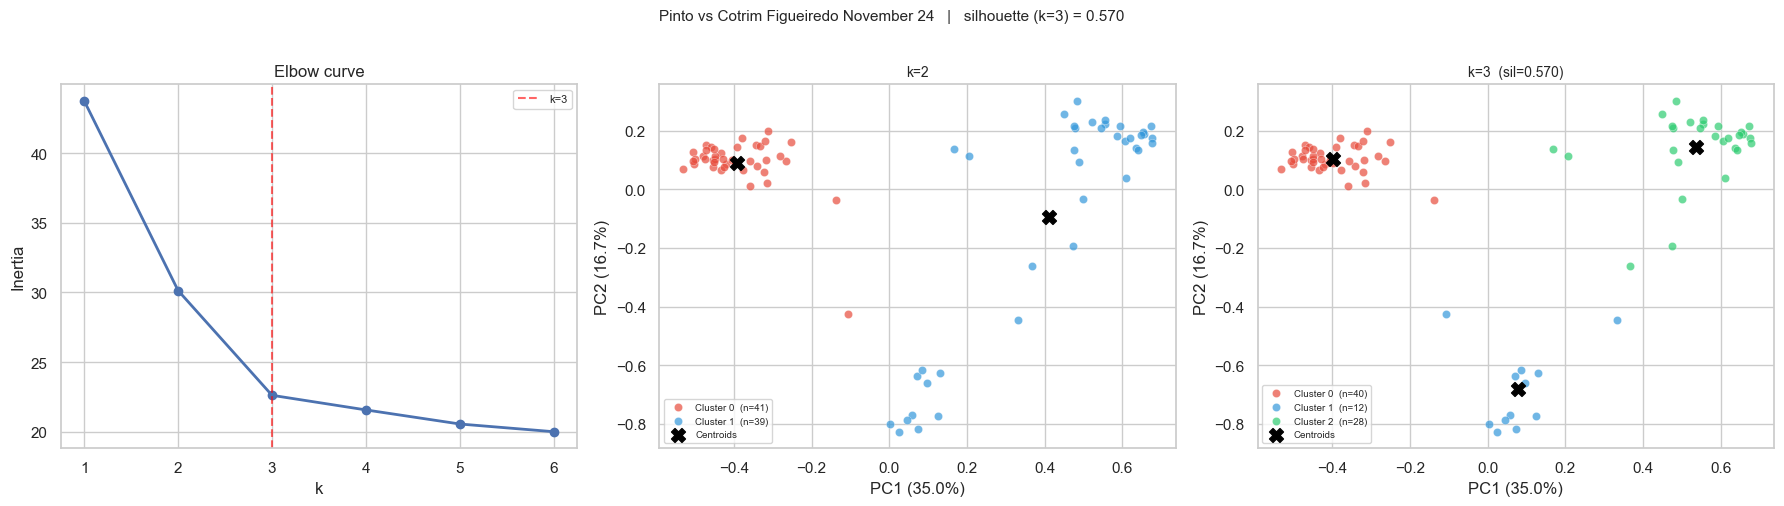

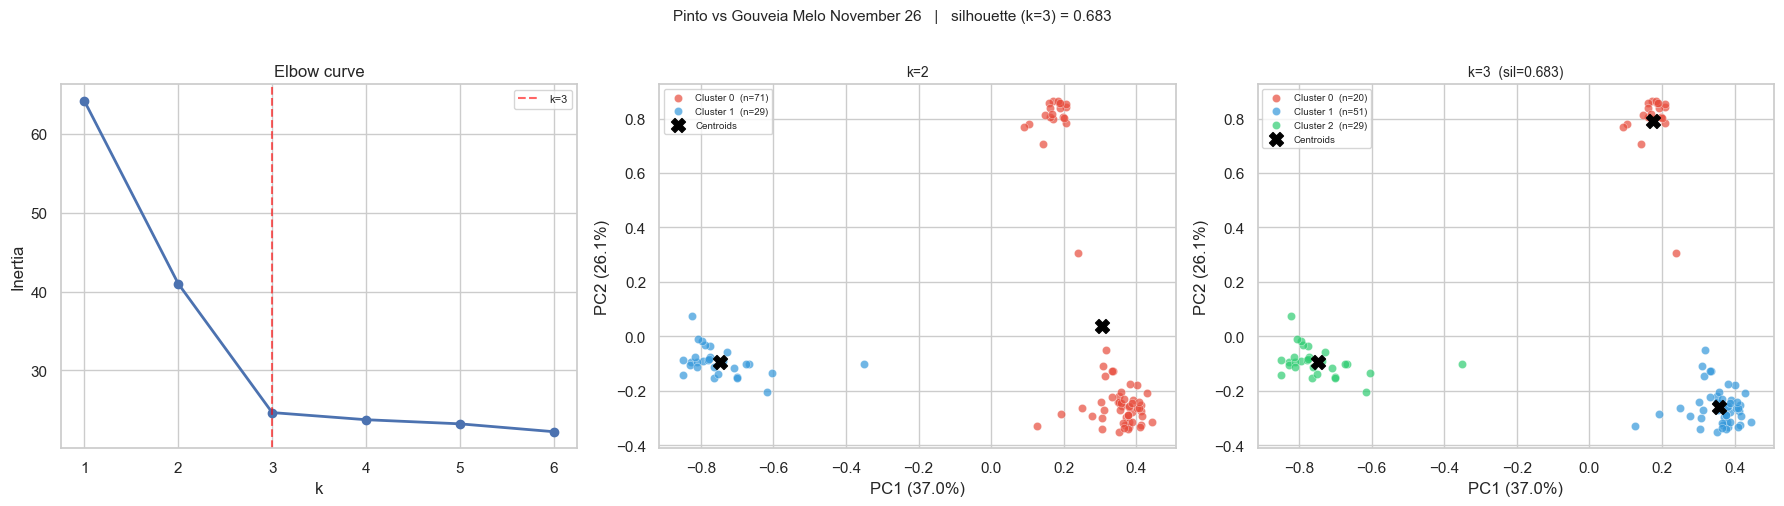

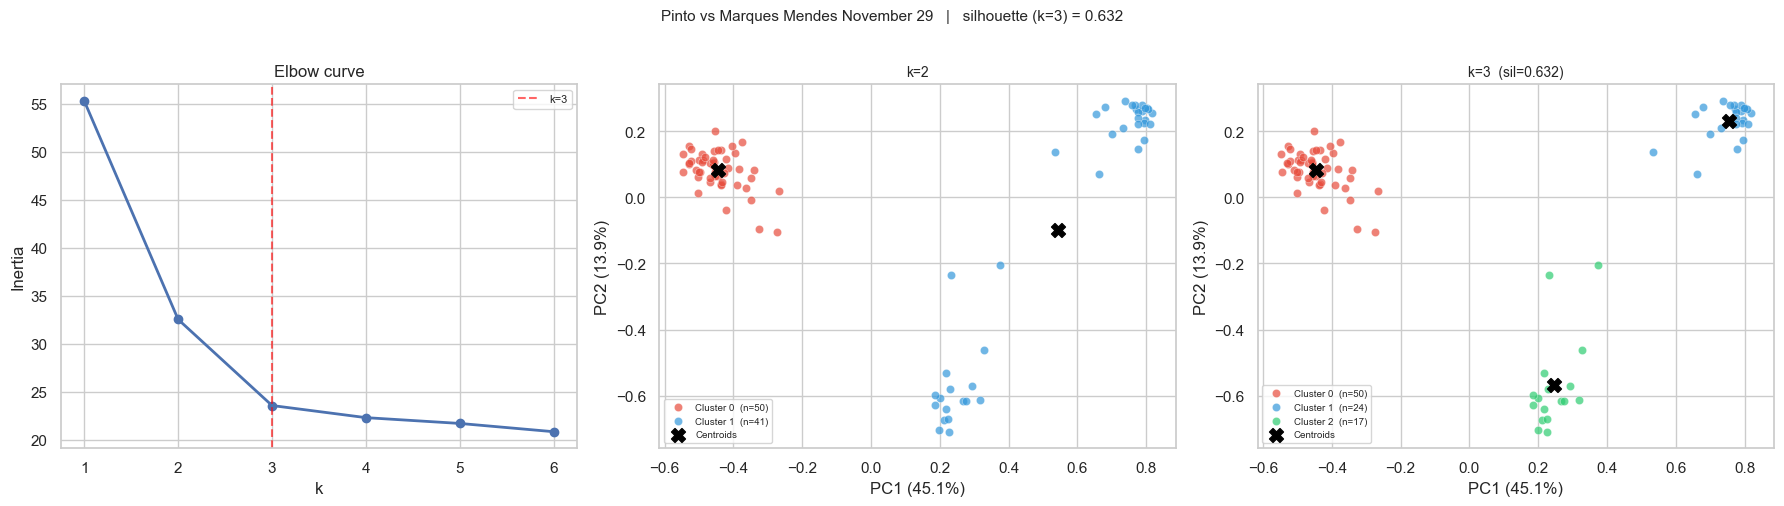

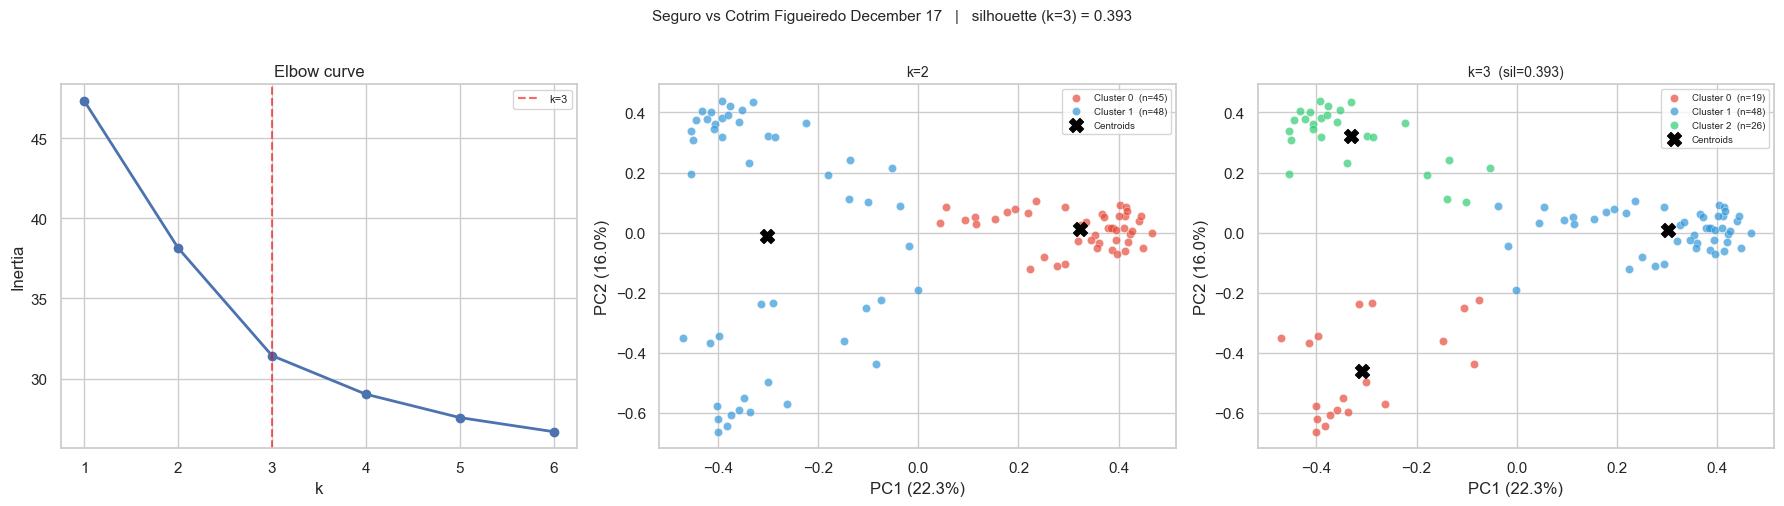

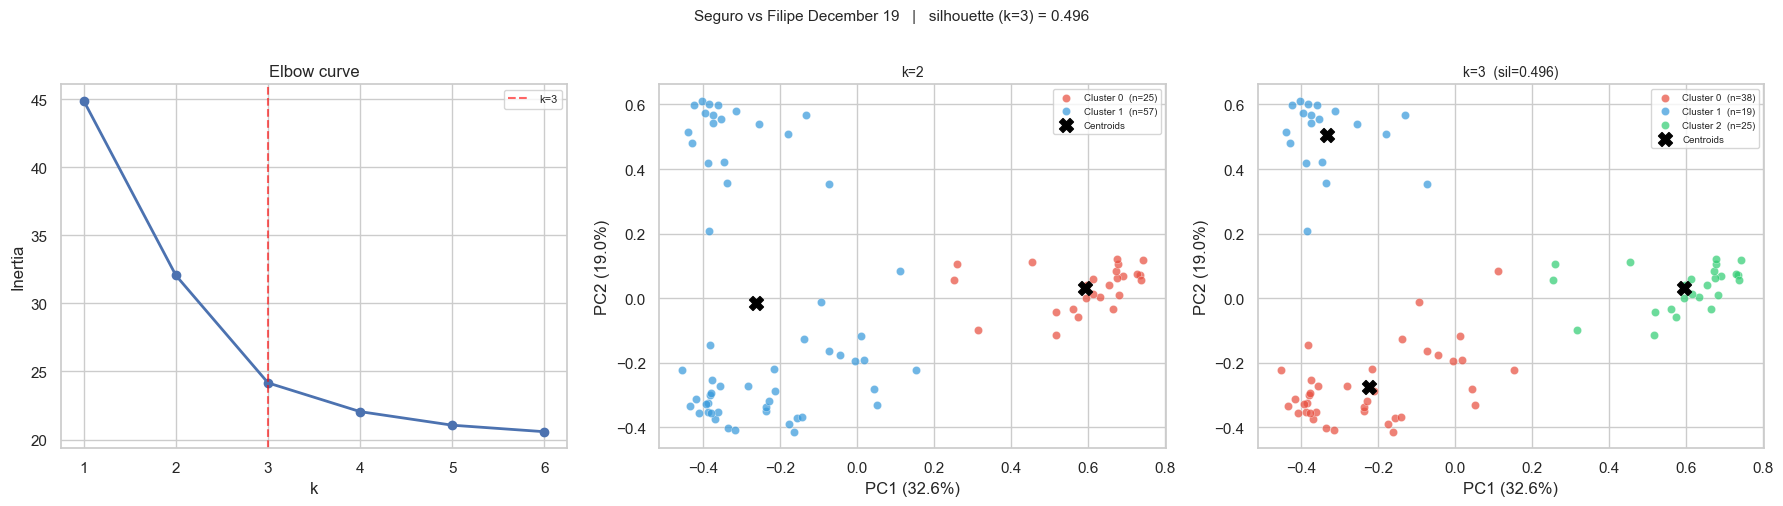

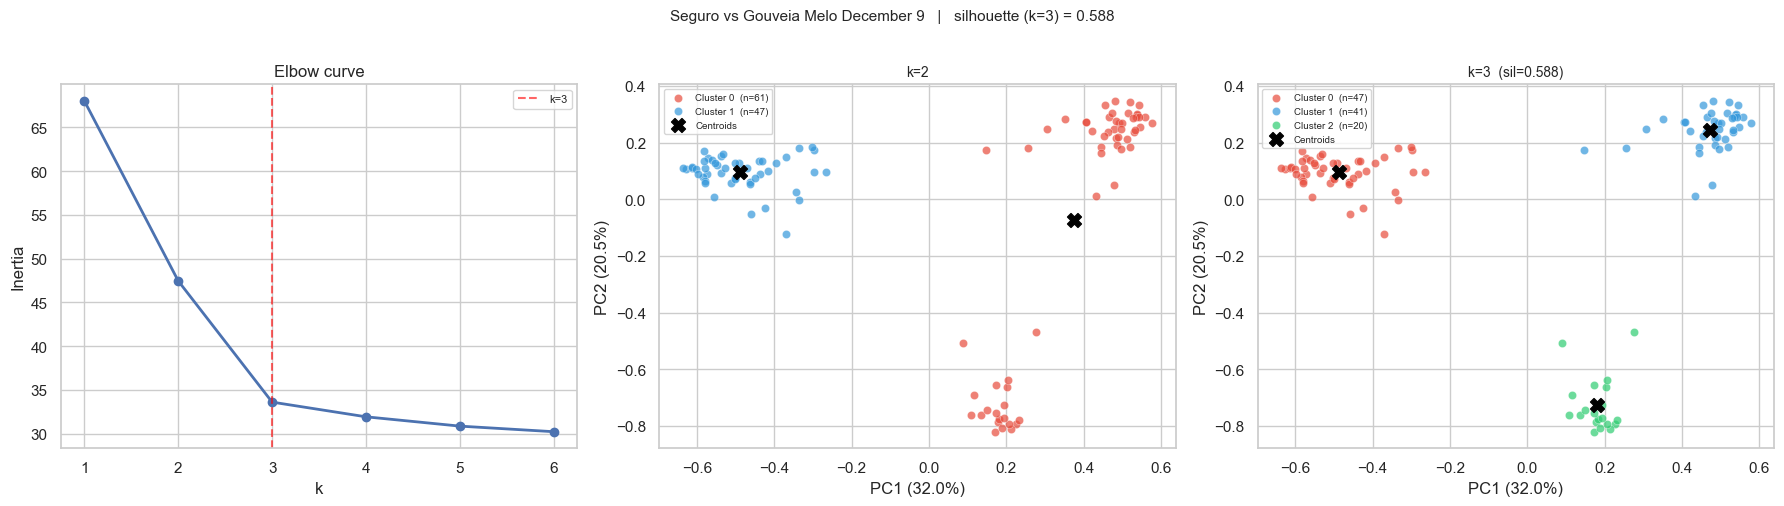

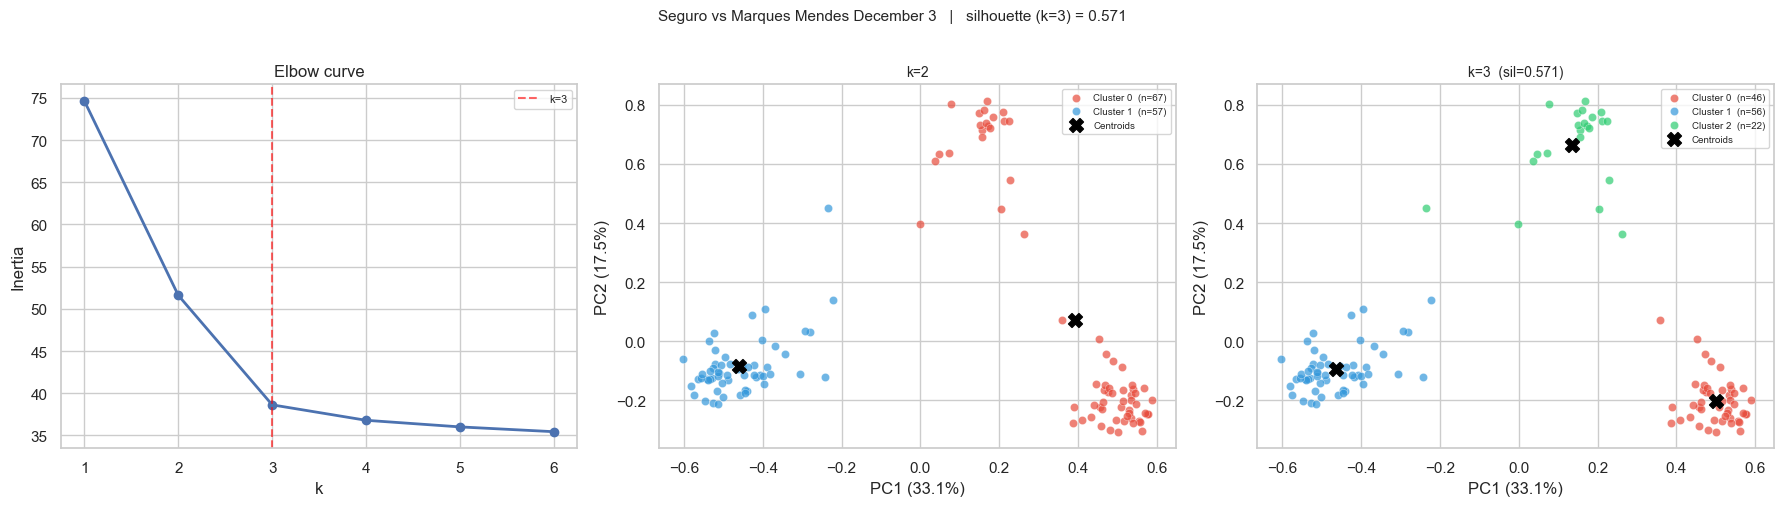

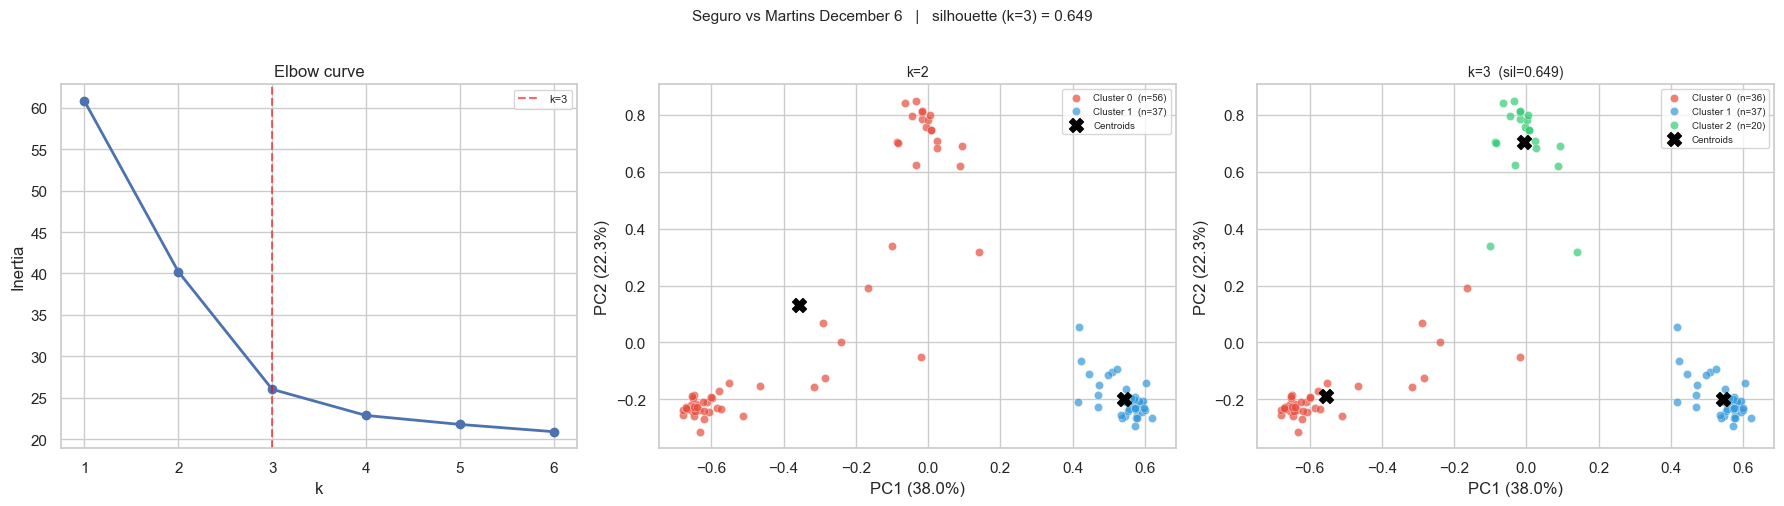

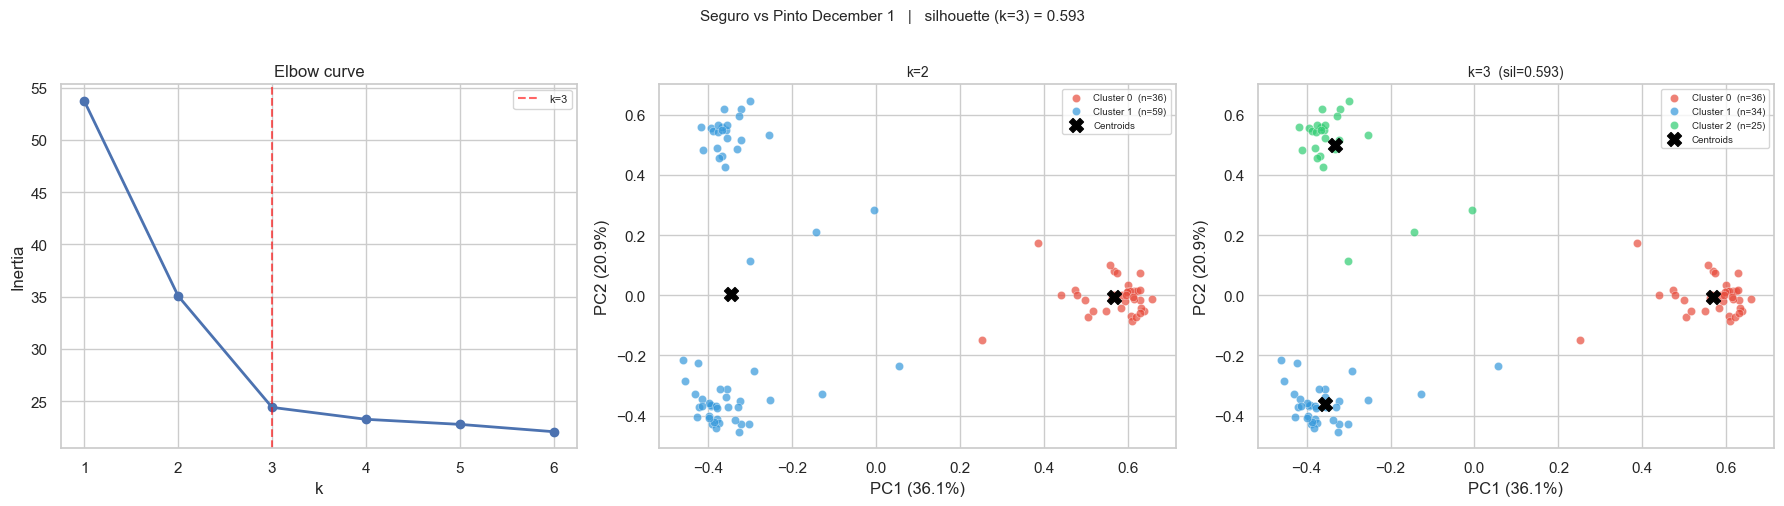

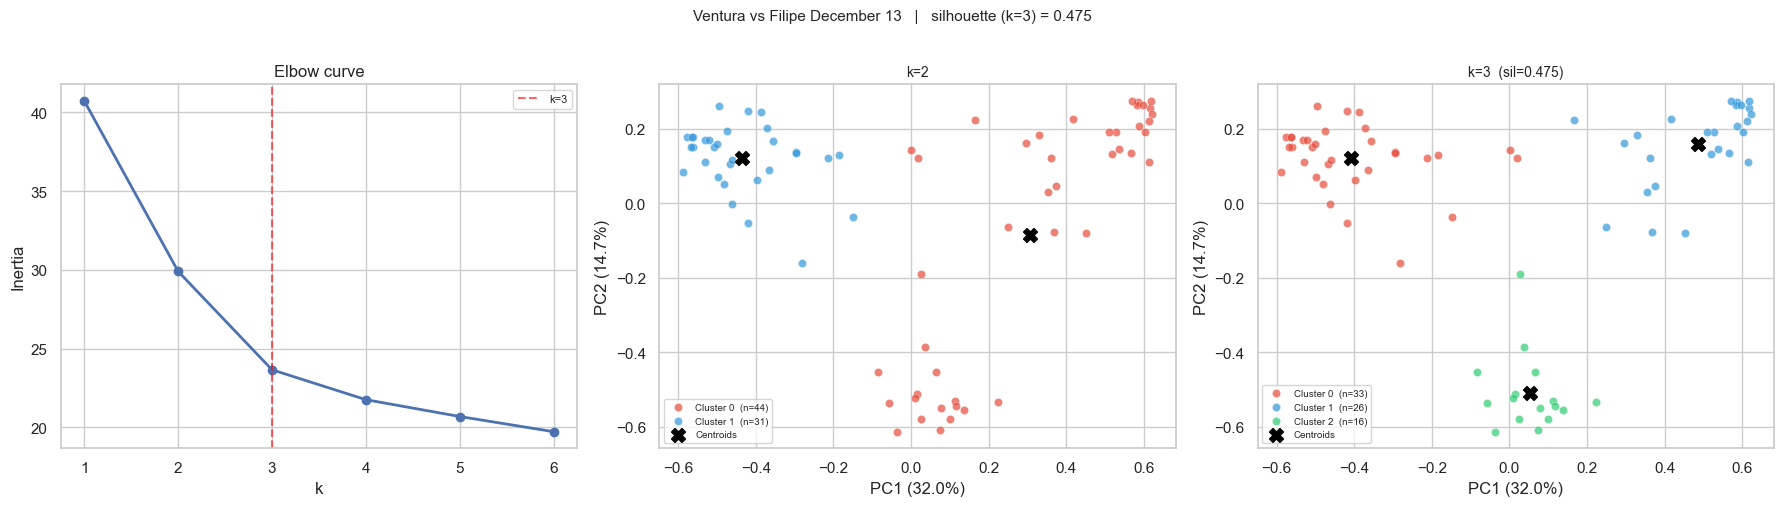

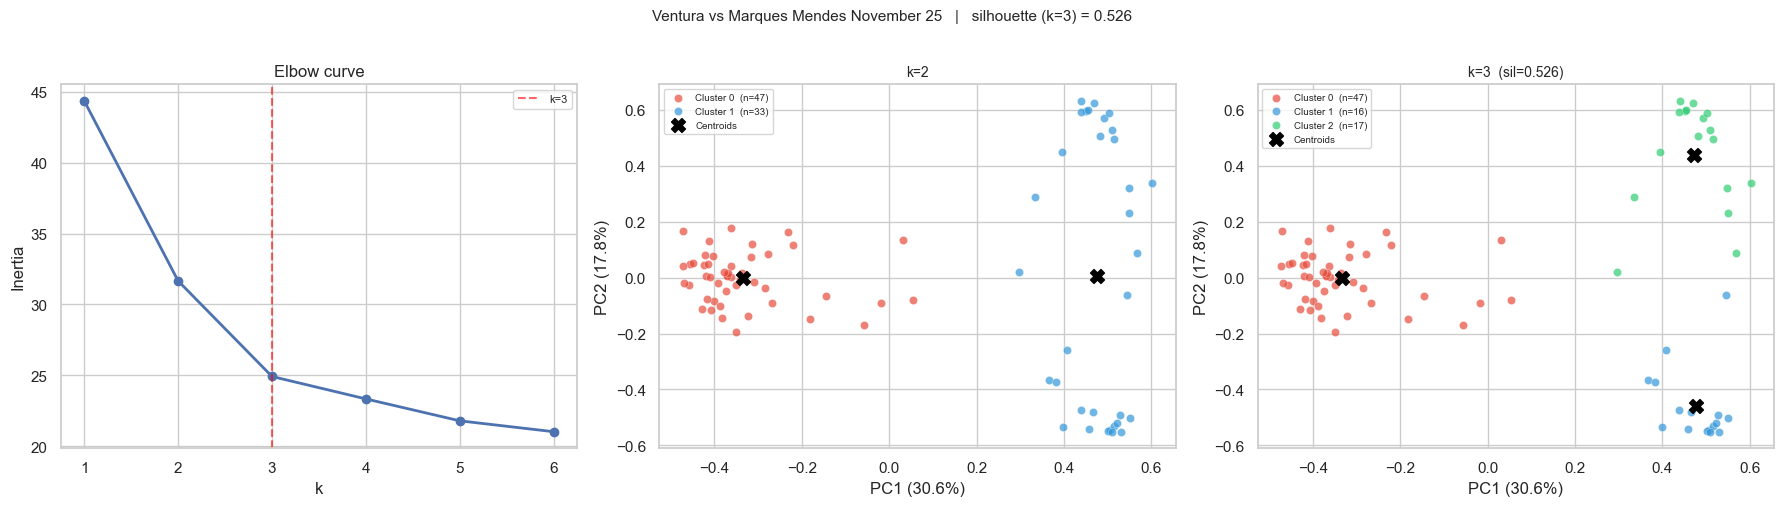

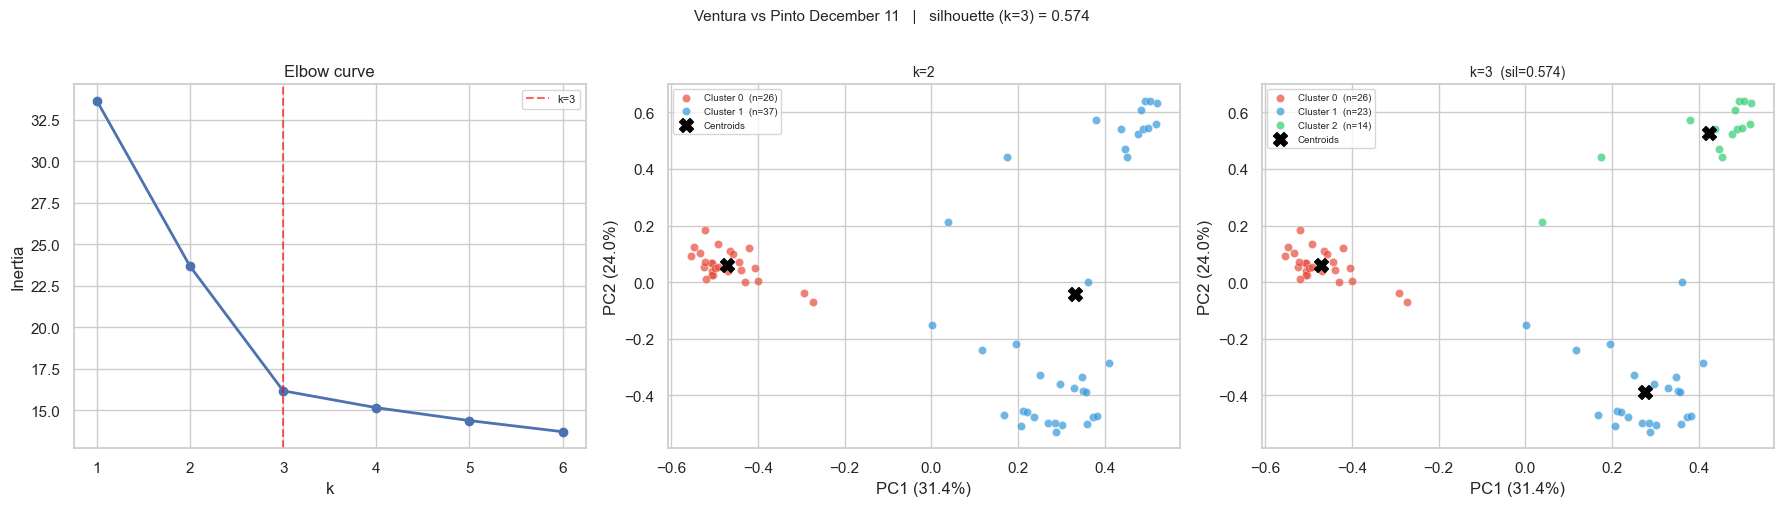

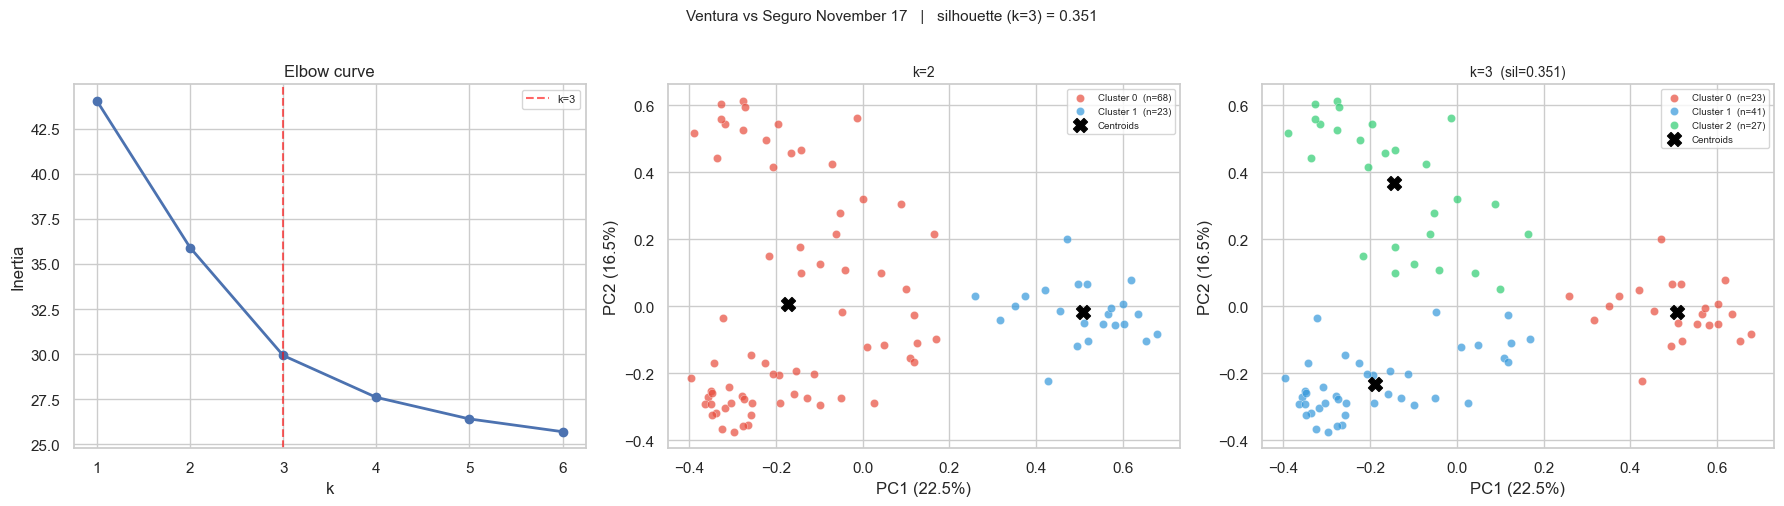

Done. quality_scores computed for 28 debates.


In [ ]:
os.makedirs('figs/debate_clusters', exist_ok=True)

quality_scores = {}  # { video_name: silhouette score at k=3 }

for video_name in debate_videos:
    dbt = data[data['video'] == video_name].copy().reset_index(drop=True)
    E = np.stack(dbt['speak_embeddings'].values)

    pca = PCA(n_components=2, random_state=42)
    E_2d = pca.fit_transform(E)
    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100

    ks = range(1, 7)
    inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

    km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_k3 = km3.fit_predict(E)
    sil = silhouette_score(E, labels_k3, metric='cosine')
    quality_scores[video_name] = sil

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{video_name.replace("_", " ")}   |   silhouette (k=3) = {sil:.3f}', fontsize=11, y=1.01)

    axes[0].plot(list(ks), inertias, marker='o', linewidth=2)
    axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('Elbow curve')
    axes[0].legend(fontsize=8)

    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for ax, k, title, precomputed in zip(
        axes[1:], [2, 3],
        ['k=2', f'k=3  (sil={sil:.3f})'],
        [None, labels_k3]
    ):
        if precomputed is None:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(E)
            centers = km.cluster_centers_
        else:
            labels = precomputed
            centers = km3.cluster_centers_

        for i in range(k):
            mask = labels == i
            ax.scatter(E_2d[mask, 0], E_2d[mask, 1], c=colors[i],
                       label=f'Cluster {i}  (n={mask.sum()})',
                       alpha=0.7, s=35, edgecolors='white', linewidth=0.3)
        centroids_2d = pca.transform(centers)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=100, zorder=5, label='Centroids')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(f'PC1 ({var1:.1f}%)')
        ax.set_ylabel(f'PC2 ({var2:.1f}%)')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'figs/debate_clusters/{video_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'Done. quality_scores computed for {len(quality_scores)} debates.')

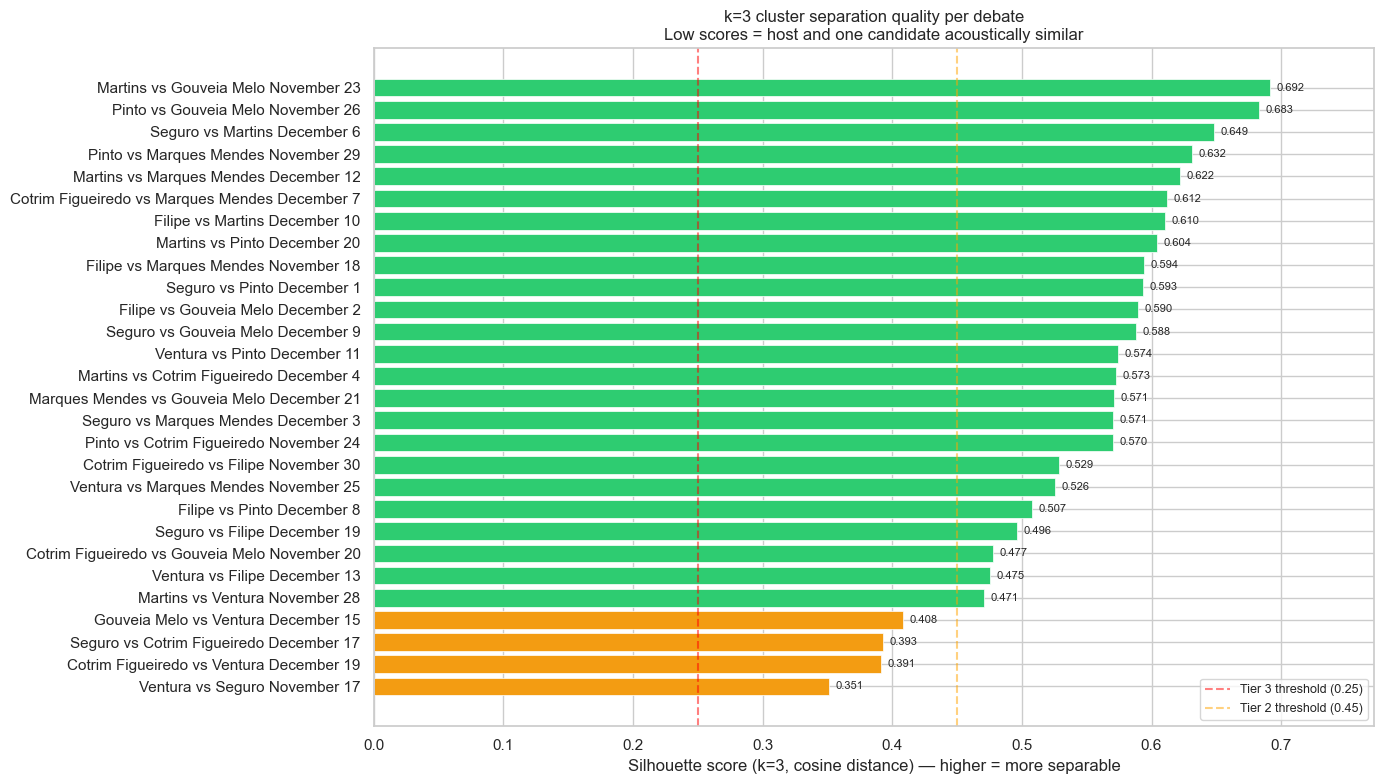

── Tier 1 — reliable   (sil >= 0.45) ──
  0.692  Martins  vs  Gouveia_Melo
  0.683  Pinto  vs  Gouveia_Melo
  0.649  Seguro  vs  Martins
  0.632  Pinto  vs  Marques_Mendes
  0.622  Martins  vs  Marques_Mendes
  0.612  Cotrim_Figueiredo  vs  Marques_Mendes
  0.610  Filipe  vs  Martins
  0.604  Martins  vs  Pinto
  0.594  Filipe  vs  Marques_Mendes
  0.593  Seguro  vs  Pinto
  0.590  Filipe  vs  Gouveia_Melo
  0.588  Seguro  vs  Gouveia_Melo
  0.574  Ventura  vs  Pinto
  0.573  Martins  vs  Cotrim_Figueiredo
  0.571  Marques_Mendes  vs  Gouveia_Melo
  0.571  Seguro  vs  Marques_Mendes
  0.570  Pinto  vs  Cotrim_Figueiredo
  0.529  Cotrim_Figueiredo  vs  Filipe
  0.526  Ventura  vs  Marques_Mendes
  0.507  Filipe  vs  Pinto
  0.496  Seguro  vs  Filipe
  0.477  Cotrim_Figueiredo  vs  Gouveia_Melo
  0.475  Ventura  vs  Filipe
  0.471  Martins  vs  Ventura

── Tier 2 — moderate   (0.25 <= sil < 0.45) ──
  0.408  Gouveia_Melo  vs  Ventura
  0.393  Seguro  vs  Cotrim_Figueiredo
  0.391  Cotrim

In [ ]:
def score_to_color(s):
    if s < 0.25:   return '#e74c3c'
    elif s < 0.45: return '#f39c12'
    else:          return '#2ecc71'

sorted_debates = sorted(quality_scores.items(), key=lambda x: x[1])
names  = [v.replace('_', ' ') for v, _ in sorted_debates]
scores = [s for _, s in sorted_debates]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(names, scores,
               color=[score_to_color(s) for s in scores],
               edgecolor='white', linewidth=0.5)

for bar, s in zip(bars, scores):
    ax.text(s + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{s:.3f}', va='center', fontsize=8)

ax.axvline(x=0.25, color='red',    linestyle='--', alpha=0.5, label='Tier 3 threshold (0.25)')
ax.axvline(x=0.45, color='orange', linestyle='--', alpha=0.5, label='Tier 2 threshold (0.45)')
ax.set_xlabel('Silhouette score (k=3, cosine distance) — higher = more separable')
ax.set_title('k=3 cluster separation quality per debate\nLow scores = host and one candidate acoustically similar', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, max(scores) + 0.08)
plt.tight_layout()
plt.show()

for tier, label, lo, hi in [
    (1, 'Tier 1 — reliable   (sil >= 0.45)', 0.45, 1.0),
    (2, 'Tier 2 — moderate   (0.25 <= sil < 0.45)', 0.25, 0.45),
    (3, 'Tier 3 — unreliable (sil < 0.25)', 0.0, 0.25),
]:
    print(f'── {label} ──')
    for v, s in sorted(quality_scores.items(), key=lambda x: -x[1]):
        if lo <= s < hi:
            cA, cB = extract_candidates(v)
            print(f'  {s:.3f}  {cA}  vs  {cB}')
    print()